<a href="https://colab.research.google.com/github/AnnaMartin-KV/AnnaMartin.github.io/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`HOUSE PRICE PREDICTION`**

**About the dataset:**

This notebook utilizes the California Housing dataset, which contains information about median house values in various districts of California.

The dataset has 20640 instances and 9 attributes:
- **MedInc**: Median income in block group
- **HouseAge**: Median house age in block group
- **AveRooms**: Average number of rooms per household
- **AveBedrms**: Average number of bedrooms per household
- **Population**: Block group population
- **AveOccup**: Average number of household members
- **Latitude**: Block group latitude
- **Longitude**: Block group longitude
- **price**: Median house value for California districts (Target Variable)

**Importing the Libraries**

This section imports the necessary Python libraries for building and evaluating the house price prediction model. Key libraries include:

- **numpy**: For numerical operations.
- **pandas**: For data manipulation and analysis using DataFrames.
- **matplotlib.pyplot** and **seaborn**: For creating various plots and visualizations.
- **sklearn.datasets**: To load the California Housing dataset.
- **sklearn.model_selection.train_test_split**: To split the data into training and testing sets.
- **xgboost.XGBRegressor**: The machine learning model used for prediction.
- **sklearn.metrics**: For evaluating model performance.

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

**Importing the California House Price Dataset**

 This function downloads the dataset and returns a dictionary-like object containing the data, target variable, feature names, and a description of the dataset.

In [ ]:
house_price_dataset = sklearn.datasets.fetch_california_housing()

In [ ]:
#printing the dataset
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

**Dataframe creation**

The code cell below converts the loaded dataset from a dictionary-like object into a pandas DataFrame.By creating a pandas DataFrame, the data becomes easier to work with for analysis and manipulation using pandas' built-in functions.

In [ ]:
# Loading the dataset to a pandas dataframe
house_price_dataframe = pd.DataFrame(house_price_dataset.data, columns = house_price_dataset.feature_names)


In [ ]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# add the target column to the dataframe
house_price_dataframe['price'] = house_price_dataset.target

In [ ]:
#Describing the Head Of The DataFrame.
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Data Audit & Availability Check**

The following code cells perform basic data audit checks to understand the structure and completeness of the dataset.

- Checking the number of rows and columns to understand the dataset's size.
- Checking for missing values to identify any gaps in the data.
- Displaying statistical measures to get a summary of the central tendency, dispersion, and shape of the dataset's distribution.

In [ ]:
# checking the number of rows and columns in the dataframe
house_price_dataframe.shape

(20640, 9)

In [ ]:
# check for missing values
# We Are Not Doing Data Cleaning Because It Was Already Pre-Processed
# No Null Values Were Present In The Dataset
house_price_dataframe.isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of        MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  price
0       False     False     False  ...     False      False  False
1       False     False     False  ...     False      False  False
2       False     False     False  ...     False      False  False
3       False     False     False  ...     False      False  False
4       False     False     False  ...     False      False  False
...       ...       ...       ...  ...       ...        ...    ...
20635   False     False     False  ...     False      False  False
20636   False     False     False  ...     False      False  False
20637   False     False     False  ...     False      False  False
20638   False     False     False  ...     False      False  False
20639   False     False     False  ...     False      False  False

[20640 rows x 9 columns]>

In [ ]:
# statistical measures of the dataset
house_price_dataframe.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Checking the duplicate values

In [ ]:
# Check for duplicates
house_price_dataframe.duplicated().sum()

Checking the unique value count

In [ ]:
# Unique value counts per column
print("\nUnique value counts:\n", house_price_dataframe.nunique())

**Data Cleaning**

Upon loading and inspecting the dataset, we found:
- The dataset contains 20,640 rows and 9 columns.
- **No missing values**: Every row is complete, with no NaN or null entries.
- **No duplicate records**: Each data point is unique, ensuring no redundancy.
- **Consistent data types**: All columns have appropriate numeric types, ready for analysis.
- All features are relevant to the problem statement.


This means we can skip traditional data cleaning steps. The dataset is already in a clean and usable format, allowing us to proceed directly to visualization, feature engineering, and model training.

**Exploratory Data Analysis (EDA)**

This helps you understand patterns and relationships.

Understanding the **correlation** between various features in the dataset

- Positive Correlation

- Negative Correlation

To understand relationships between features and between features and the target

**What You Learn:**
- Which features are strongly related to the target (good predictors).
- Which features are redundant (e.g., two columns that are almost identical).
- Which features might be irrelevant (low correlation with target).

**How It Helps Your Model:**
- You can select the most useful features and drop the rest (feature selection).
- You can avoid multicollinearity—when two features are too similar, they confuse the model.
- You can engineer new features based on strong relationships (e.g., ratios, interactions).

In [ ]:
correlation = house_price_dataframe.corr()

<Axes: >

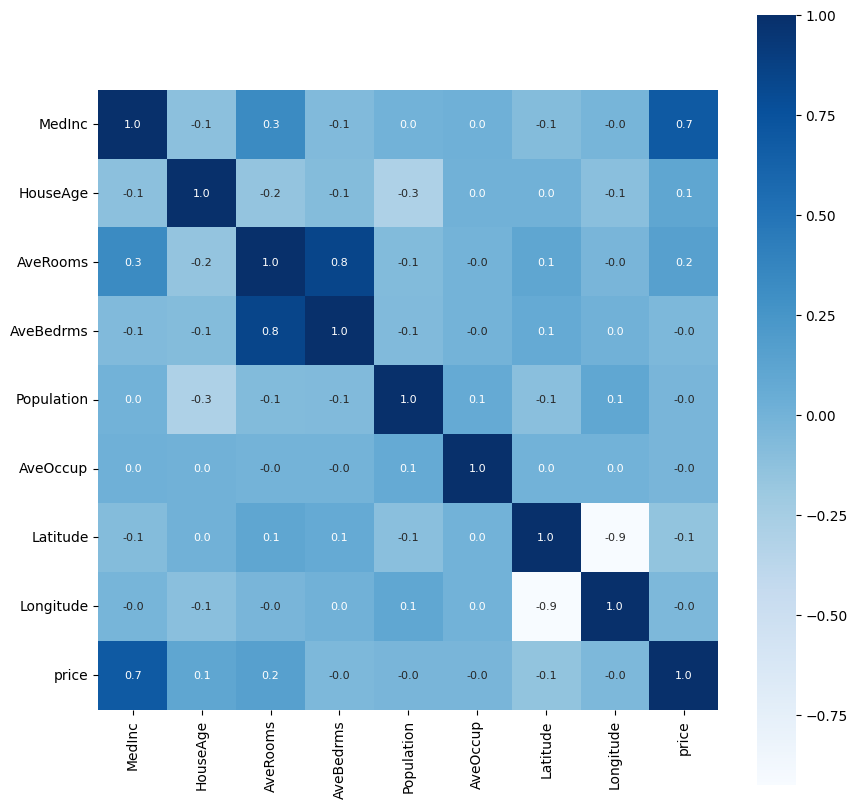

In [ ]:
# Constructing A HeatMap To Understand The Correlation Of The Features
# Other Types of Plots are not Applicable here because we required to co-relte the features .

plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

**Insight from Correlation Heatmap**

The correlation heatmap reveals key relationships between housing features and the target variable price
- Median Income (MedInc) shows the strongest positive correlation with price at **0.7**, indicating that higher-income areas tend to have more expensive houses.
- Average Bedrooms (AveBedrms) and Average Rooms (AveRooms) have a high inter-correlation of **0.8**, which may introduce multicollinearity.
- Latitude and Longitude are highly correlated (**0.9**), reflecting their geographic dependency.
- Population and Average Occupancy (AveOccup) show weak correlations with price, indicating limited direct influence.

**Correlation is used because:**

Since all features in the dataset are numeric, using a correlation matrix is the most appropriate method to assess relationships between variables. Correlation quantifies the linear association between pairs of continuous features, helping us:
- Identify which features are strongly related to the target variable (price)
- Detect multicollinearity between predictors
- Prioritize features for model training and feature selection


Splitting the data and target

In [ ]:
X = house_price_dataframe.drop(['price'], axis=1)
Y = house_price_dataframe['price']

In [ ]:
print(X,Y)

       MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
0      8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
1      8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
2      7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
3      5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
4      3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25
...       ...       ...       ...  ...       ...       ...        ...
20635  1.5603      25.0  5.045455  ...  2.560606     39.48    -121.09
20636  2.5568      18.0  6.114035  ...  3.122807     39.49    -121.21
20637  1.7000      17.0  5.205543  ...  2.325635     39.43    -121.22
20638  1.8672      18.0  5.329513  ...  2.123209     39.43    -121.32
20639  2.3886      16.0  5.254717  ...  2.616981     39.37    -121.24

[20640 rows x 8 columns] 0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923

Splitting the data into training data and test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [ ]:
#Checking & Printing the Shape
print(X.shape, X_train.shape, X_test.shape)

(20640, 8) (16512, 8) (4128, 8)


Model Training

XGBoost Regressor

In [ ]:
# load the model
model = XGBRegressor()

In [ ]:
#training the model with X_train
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

Evaluation

Prediction on training data

In [ ]:
# accuracy for prediction on training data
training_data_prediction = model.predict(X_train)

In [ ]:
print(training_data_prediction)

[0.6893792  2.986824   0.48874274 ... 1.8632544  1.7800125  0.7565893 ]


In [ ]:
# R Squared Error
score_1 = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print('R Sqaured Error:', score_1)
print('Mean Absolute Error:', score_2)

R Sqaured Error: 0.9451221492760822
Mean Absolute Error: 0.1919170860794262


Visualize the actuale prices and predicted prices

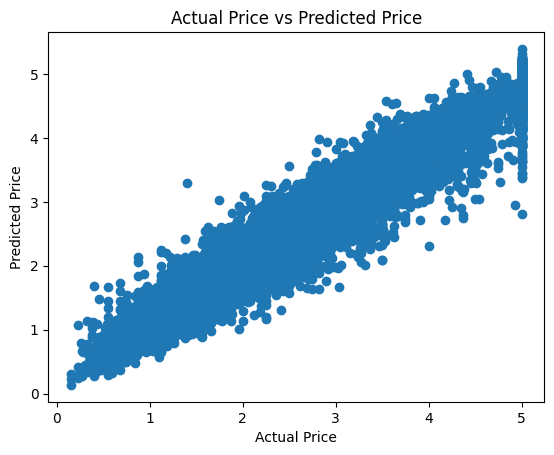

In [ ]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

Prediction on test data

In [ ]:
# accuracy for prediction on test data
test_data_prediction = model.predict(X_test)

In [ ]:
# R Squared Error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print('R Sqaured Error:', score_1)
print('Mean Absolute Error:', score_2)

R Sqaured Error: 0.8412904408180302
Mean Absolute Error: 0.30753655785801337


Exploring the relationship between Latitude, Longitude, and House Price

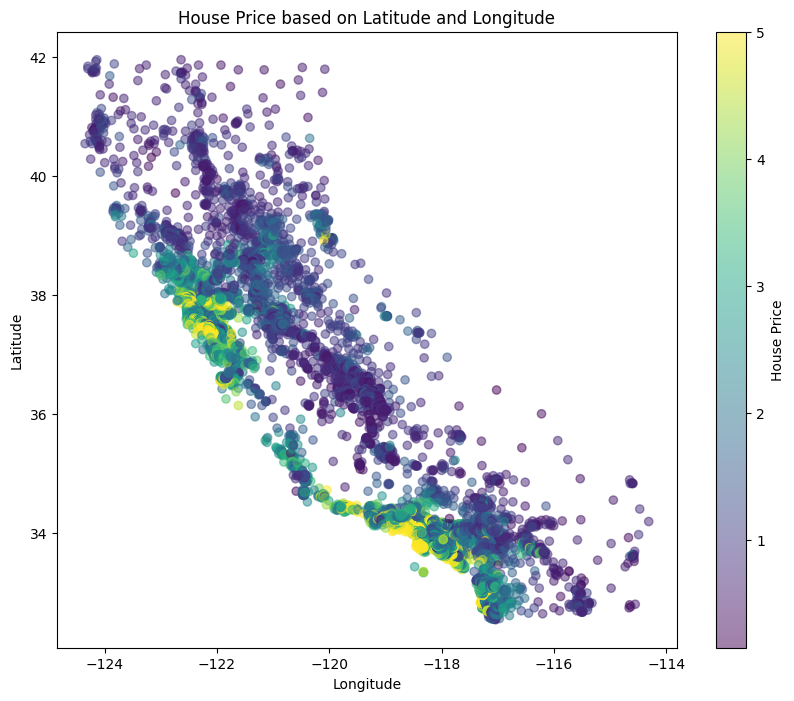

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(house_price_dataframe['Longitude'], house_price_dataframe['Latitude'], c=house_price_dataframe['price'], cmap='viridis', alpha=0.5)
plt.colorbar(label='House Price')
plt.title('House Price based on Latitude and Longitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

The scatter plot shows how house prices vary by geographic location (latitude and longitude).
We can observe that:

- Higher-priced houses (yellow shades) are clustered near the coastal areas, particularly around longitudes close to -122 to -118, which likely correspond to major cities or coastal regions.
- Lower-priced houses (purple shades) are found further inland or in less populated regions.
- This pattern suggests a strong geographical influence on house prices — properties closer to the coast or urban centers tend to have higher values, while those farther away are generally less expensive.

Exploring the relationship between Average Occupancy (AveOccup) and House Price

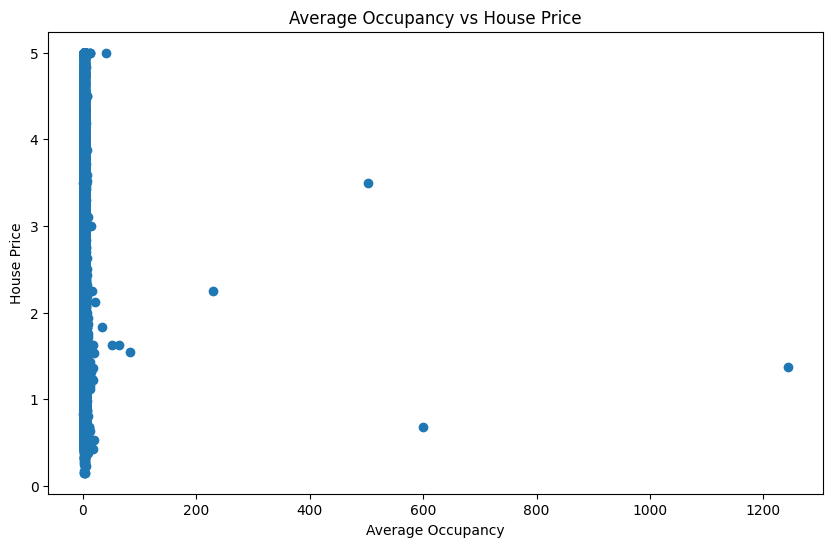

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(house_price_dataframe['AveOccup'], house_price_dataframe['price'])
plt.title('Average Occupancy vs House Price')
plt.xlabel('Average Occupancy')
plt.ylabel('House Price')
plt.show()

The scatter plot between **Average Occupancy** and **House Price** shows no clear relationship between the two variables.
Most houses have **low average occupancy** (below 5), and their prices vary widely across this range.
A few outlier points with **very high occupancy values** are visible, but they do not follow any consistent trend with house prices.

Overall, **Average Occupancy** does not appear to be a strong predictor of house price.

Exploring the relationship between Median Income (MedInc) and House Price

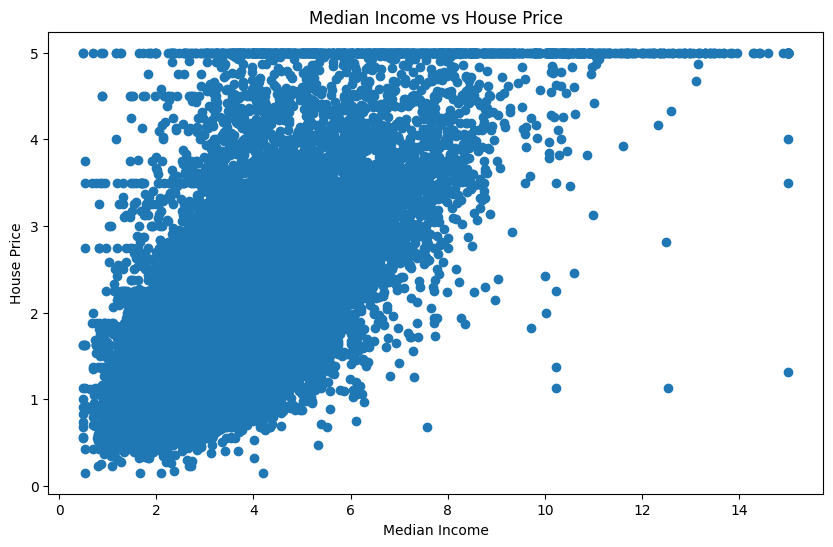

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(house_price_dataframe['MedInc'], house_price_dataframe['price'])
plt.title('Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.show()

Visualizing Feature Importances

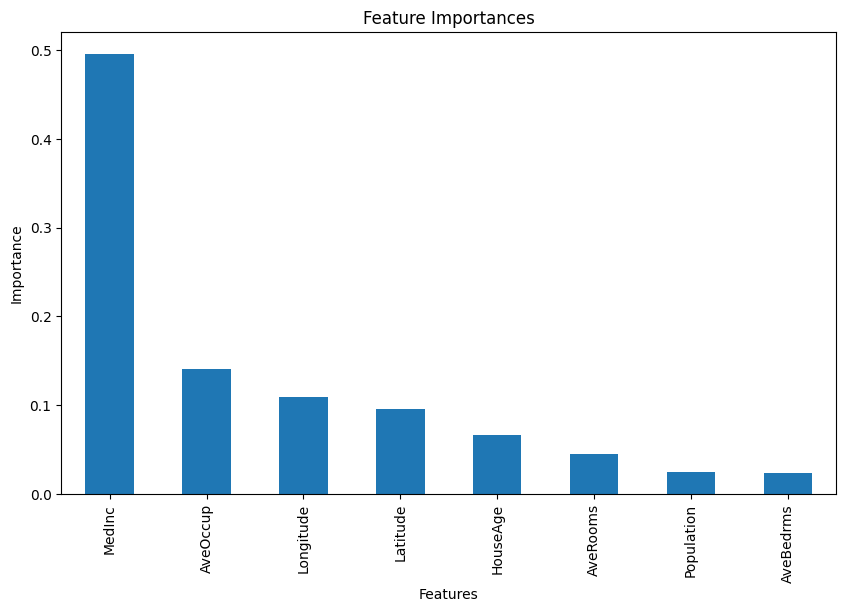

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import sklearn.datasets

# Load the dataset
house_price_dataset = sklearn.datasets.fetch_california_housing()

# Loading the dataset to a pandas dataframe
house_price_dataframe = pd.DataFrame(house_price_dataset.data, columns = house_price_dataset.feature_names)

# add the target column to the dataframe
house_price_dataframe['price'] = house_price_dataset.target

# Splitting the data and target
X = house_price_dataframe.drop(['price'], axis=1)
Y = house_price_dataframe['price']

# Splitting the data into training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

# Initialize and train the model
model = XGBRegressor()
model.fit(X_train, Y_train)

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a pandas Series for easier plotting
feature_importances_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sorted_feature_importances.plot(kind='bar')
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()